# Classificacao de Qualidade de Vinhos com Redes Neurais Artificiais

**Disciplina:** Inteligencia Artificial  
**Professor:** Marcio Andrey Roselli  
**Aluno:** Bruno Araújo Sales  
**Instituicao:** Universidade do Distrito Federal (UnDF)  
**Turma:** Engenharia de Software 6° Semestre

Este notebook resolve a tarefa de classificacao binaria do dataset Wine Quality, compara uma rede neural feedforward com um baseline de regressao logistica e discute criticamente os resultados.


## 1. Importacoes e configuracao


> **O que esta celula faz**  
> Importa bibliotecas basicas de manipulacao de arquivos, calculo numerico, tabelas e visualizacao grafica. Ela prepara o ambiente para carregar os dados e construir os graficos do notebook.


In [41]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

> **O que esta celula faz**  
> Importa as ferramentas de machine learning, define a semente aleatoria para reprodutibilidade, configura o estilo visual dos graficos e cria funcoes auxiliares para avaliacao dos modelos e controle do treinamento com `EarlyStopping` e `ReduceLROnPlateau`.


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(context="notebook", style="whitegrid")


def evaluate_classifier(y_true, y_pred, y_score, model_name):
    return {
        "modelo": model_name,
        "acuracia": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


def print_metric_block(metrics_dict):
    print(f"Modelo: {metrics_dict['modelo']}")
    print(f"  Acuracia : {metrics_dict['acuracia']:.4f}")
    print(f"  Precision: {metrics_dict['precision']:.4f}")
    print(f"  Recall   : {metrics_dict['recall']:.4f}")
    print(f"  F1-score : {metrics_dict['f1']:.4f}")
    print(f"  ROC-AUC  : {metrics_dict['roc_auc']:.4f}")
    print(f"  PR-AUC   : {metrics_dict['pr_auc']:.4f}")


def make_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=12,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
            verbose=1,
        ),
    ]


print("Bibliotecas importadas com sucesso.")


Bibliotecas importadas com sucesso.


## 2. Carregamento dos dados

O notebook usa apenas um arquivo local. Salve `winequality-red.csv` na mesma pasta do notebook ou em `data/winequality-red.csv` antes de executar as celulas.


> **O que esta celula faz**  
> Procura o arquivo CSV em caminhos locais, carrega o dataset, cria a variavel alvo binaria e separa os atributos de entrada. Ao final, mostra a origem do arquivo, o tamanho do conjunto e a distribuicao das classes.


In [43]:
data_candidates = [
    Path("winequality-red.csv"),
    Path("data") / "winequality-red.csv",
]
df = None
data_source = None

for candidate in data_candidates:
    if candidate.exists():
        df = pd.read_csv(candidate, sep=";")
        data_source = f"arquivo local: {candidate}"
        break

if df is None:
    raise FileNotFoundError(
        "Arquivo 'winequality-red.csv' nao encontrado. "
        "Coloque o CSV na mesma pasta do notebook ou em ./data/."
    )

df["alvo"] = (df["quality"] >= 7).astype(int)
atributos = [col for col in df.columns if col not in ["quality", "alvo"]]

print(f"Fonte dos dados: {data_source}")
print(f"Dimensoes do dataset: {df.shape}")
print(f"Classes binaria: {df['alvo'].value_counts().to_dict()}")
df.head()


Fonte dos dados: arquivo local: winequality-red.csv
Dimensoes do dataset: (1599, 13)
Classes binaria: {0: 1382, 1: 217}


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alvo
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


## 3. Analise exploratoria


> **O que esta celula faz**  
> Exibe estatisticas descritivas dos atributos, verifica valores ausentes e plota a distribuicao da nota original e da classe binaria. O objetivo e entender a estrutura geral dos dados e confirmar o desbalanceamento entre as classes.


,mean,std,min,max
fixed acidity,8.319637,1.741096,4.60000,15.90000
volatile acidity,0.527821,0.179060,0.12000,1.58000
citric acid,0.270976,0.194801,0.00000,1.00000
residual sugar,2.538806,1.409928,0.90000,15.50000
chlorides,0.087467,0.047065,0.01200,0.61100
free sulfur dioxide,15.874922,10.460157,1.00000,72.00000
total sulfur dioxide,46.467792,32.895324,6.00000,289.00000
density,0.996747,0.001887,0.99007,1.00369
pH,3.311113,0.154386,2.74000,4.01000
sulphates,0.658149,0.169507,0.33000,2.00000


Valores ausentes por coluna:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alvo
ausentes,0,0,0,0,0,0,0,0,0,0,0,0,0


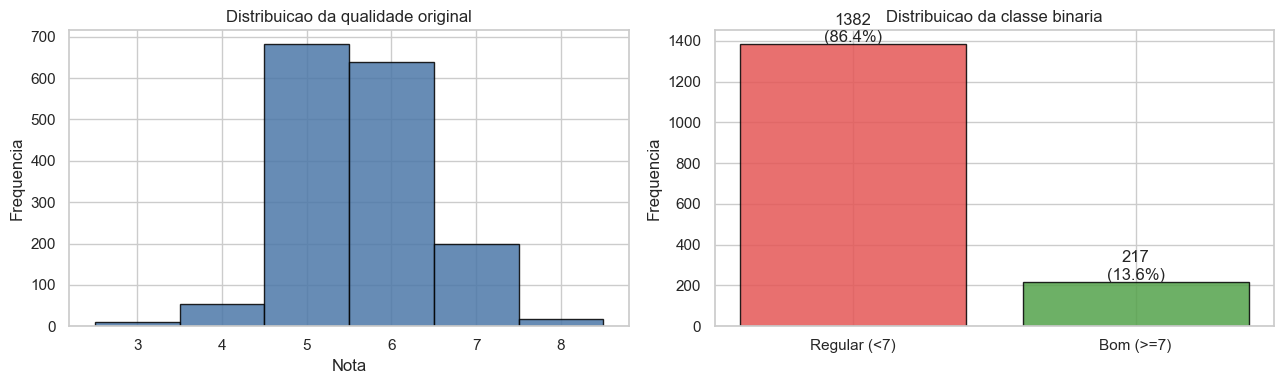

Percentual da classe positiva: 13.57%


In [44]:
display(df[atributos].describe().T[["mean", "std", "min", "max"]])

print("Valores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes").T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["quality"], bins=np.arange(df["quality"].min(), df["quality"].max() + 2) - 0.5,
             color="#4C78A8", edgecolor="black", alpha=0.85)
axes[0].set_title("Distribuicao da qualidade original")
axes[0].set_xlabel("Nota")
axes[0].set_ylabel("Frequencia")

class_counts = df["alvo"].value_counts().sort_index()
axes[1].bar(["Regular (<7)", "Bom (>=7)"], class_counts.values,
            color=["#E45756", "#54A24B"], edgecolor="black", alpha=0.85)
axes[1].set_title("Distribuicao da classe binaria")
axes[1].set_ylabel("Frequencia")

for idx, value in enumerate(class_counts.values):
    axes[1].text(idx, value + 12, f"{value}\n({value / len(df):.1%})", ha="center")

plt.tight_layout()
plt.show()

print(f"Percentual da classe positiva: {df['alvo'].mean():.2%}")


> **O que esta celula faz**  
> Calcula a correlacao entre cada atributo e a variavel alvo, depois destaca visualmente as maiores correlacoes positivas e negativas. Isso ajuda a identificar quais variaveis parecem mais relacionadas com a classificacao de qualidade.


,correlacao_com_alvo
alcohol,0.407315
citric acid,0.214716
sulphates,0.199485
fixed acidity,0.120061
residual sugar,0.047779
pH,-0.057283
free sulfur dioxide,-0.071747
chlorides,-0.097308
total sulfur dioxide,-0.139517
density,-0.150460


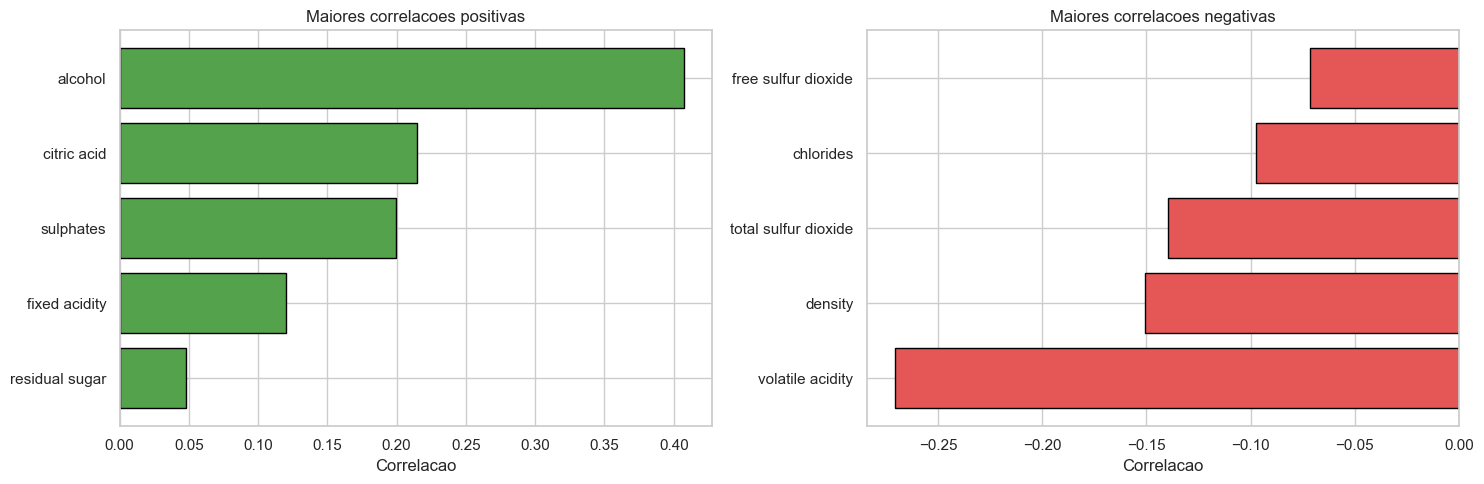

In [45]:
correlacoes = df[atributos + ["alvo"]].corr(numeric_only=True)["alvo"].drop("alvo").sort_values(ascending=False)
display(correlacoes.to_frame("correlacao_com_alvo"))

top_pos = correlacoes.head(5).sort_values()
top_neg = correlacoes.tail(5).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top_pos.index, top_pos.values, color="#54A24B", edgecolor="black")
axes[0].set_title("Maiores correlacoes positivas")
axes[0].set_xlabel("Correlacao")

axes[1].barh(top_neg.index, top_neg.values, color="#E45756", edgecolor="black")
axes[1].set_title("Maiores correlacoes negativas")
axes[1].set_xlabel("Correlacao")

plt.tight_layout()
plt.show()


> **O que esta celula faz**  
> Estima a quantidade de outliers por atributo usando a regra do IQR e plota boxplots para inspecao visual. A conclusao impressa justifica a decisao de manter esses valores por poderem representar variacao real do processo quimico.


,atributo,outliers,percentual
3,residual sugar,155,0.096936
4,chlorides,112,0.070044
9,sulphates,59,0.036898
6,total sulfur dioxide,55,0.034396
0,fixed acidity,49,0.030644
7,density,45,0.028143
8,pH,35,0.021889
5,free sulfur dioxide,30,0.018762
1,volatile acidity,19,0.011882
10,alcohol,13,0.008130


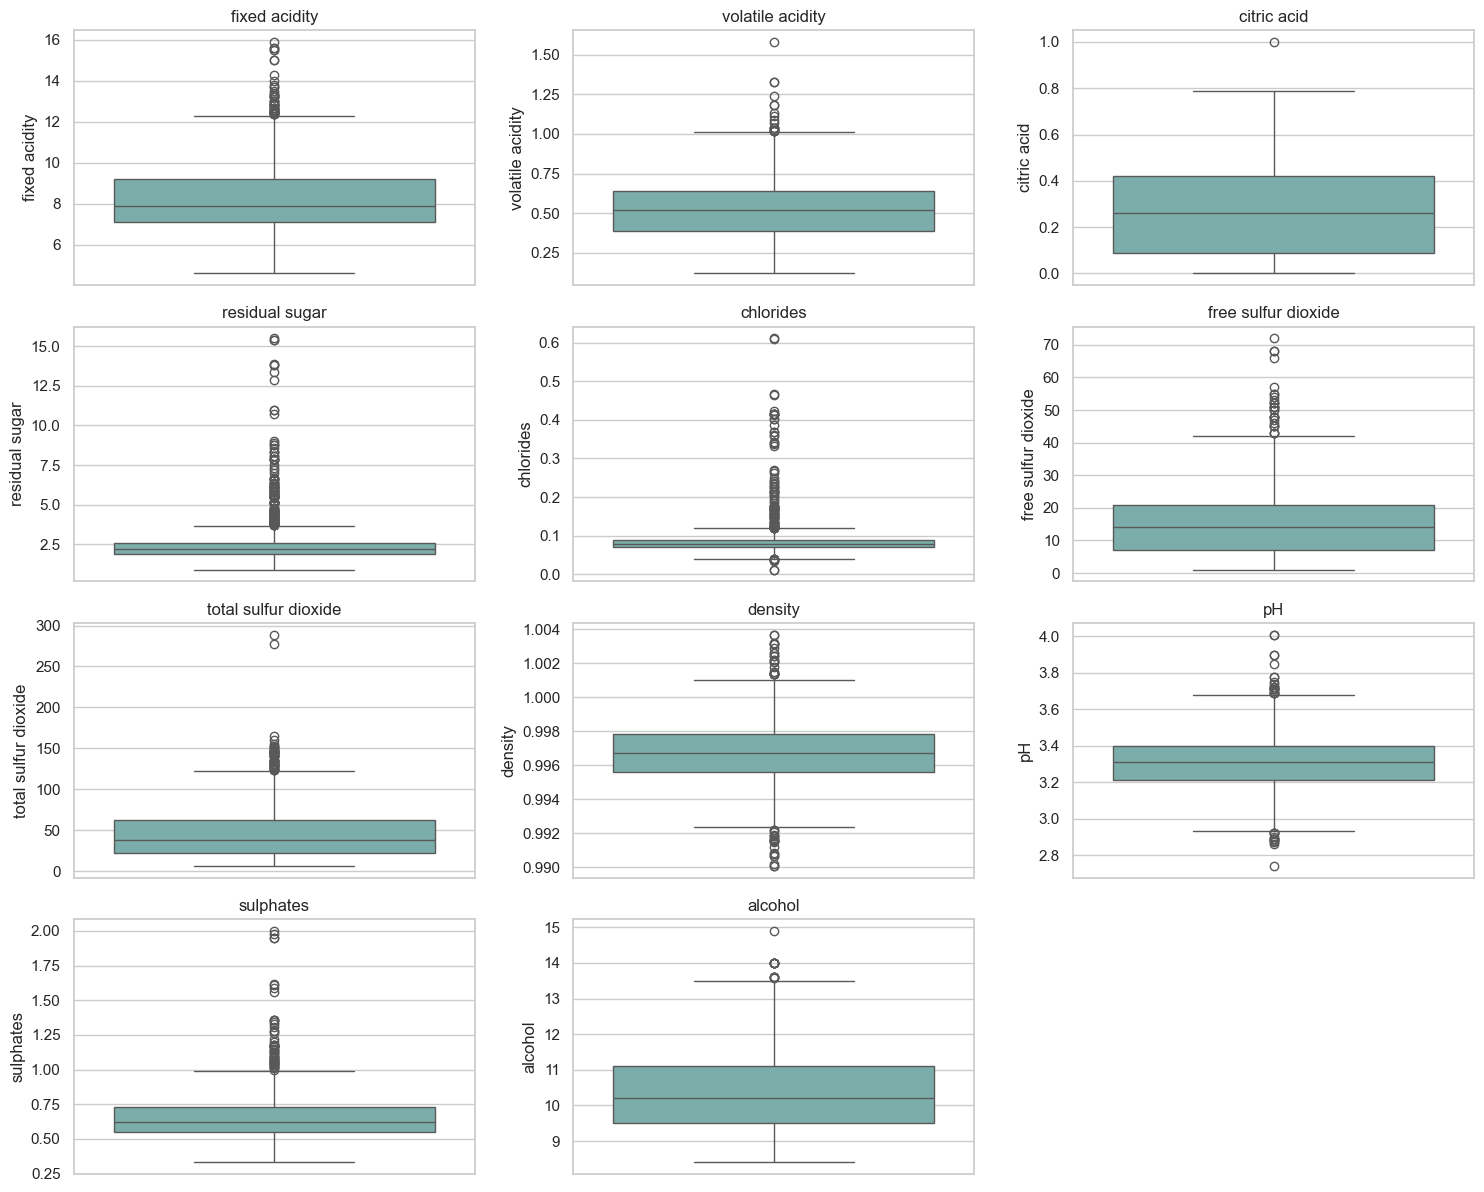

Os outliers foram mantidos porque podem carregar sinal real do processo quimico e a normalizacao reduz parte do impacto.


In [46]:
outlier_summary = []
for col in atributos:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "atributo": col,
        "outliers": int(count),
        "percentual": count / len(df),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outliers", ascending=False)
display(outlier_df)

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(atributos):
    sns.boxplot(y=df[col], ax=axes[idx], color="#72B7B2")
    axes[idx].set_title(col)
    axes[idx].set_xlabel("")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("Os outliers foram mantidos porque podem carregar sinal real do processo quimico e a normalizacao reduz parte do impacto.")


## 4. Pre-processamento

A divisao foi feita em tres partes:

- treino: 64%
- validacao: 16%
- teste: 20%

O `StandardScaler` foi ajustado apenas no treino e reaplicado em validacao e teste.


> **O que esta celula faz**  
> Separa os dados em treino, validacao e teste com estratificacao, preservando a proporcao das classes em cada subconjunto. Em seguida, aplica a padronizacao das variaveis com `StandardScaler`, ajustado apenas no treino para evitar vazamento de informacao.


In [47]:
X = df[atributos].copy()
y = df["alvo"].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Distribuicao das classes:")
for split_name, target in {
    "treino": y_train,
    "validacao": y_val,
    "teste": y_test,
}.items():
    print(f"  {split_name:10s} -> total={len(target):4d} | classe 1={target.mean():.2%}")

print("\nMedia aproximada do treino apos padronizacao:", np.round(X_train_scaled.mean(axis=0), 4))
print("Desvio padrao aproximado do treino apos padronizacao:", np.round(X_train_scaled.std(axis=0), 4))


Distribuicao das classes:
  treino     -> total=1023 | classe 1=13.59%
  validacao  -> total= 256 | classe 1=13.67%
  teste      -> total= 320 | classe 1=13.44%

Media aproximada do treino apos padronizacao: [-0.  0.  0.  0. -0.  0. -0.  0.  0.  0.  0.]
Desvio padrao aproximado do treino apos padronizacao: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


> **O que esta celula faz**  
> Cria duas estrategias para lidar com o desbalanceamento: pesos de classe (`class_weight`) e oversampling da classe minoritaria. O bloco prepara esses dois cenarios para que a rede neural possa ser treinada e comparada em condicoes diferentes.


In [48]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(np.unique(y_train), class_weights)}

train_df = pd.DataFrame(X_train_scaled, columns=atributos)
train_df["alvo"] = y_train.to_numpy()

majority = train_df[train_df["alvo"] == 0]
minority = train_df[train_df["alvo"] == 1]
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=RANDOM_STATE,
)

oversampled_train = pd.concat([majority, minority_upsampled], axis=0).sample(
    frac=1.0,
    random_state=RANDOM_STATE,
)

X_train_oversampled = oversampled_train[atributos].to_numpy()
y_train_oversampled = oversampled_train["alvo"].to_numpy()

print("Estrategia 1 - class weights:")
print(class_weight_dict)
print("\nEstrategia 2 - oversampling:")
print(f"  treino original    -> {len(y_train)} amostras | classe 1 = {y_train.mean():.2%}")
print(f"  treino oversampled -> {len(y_train_oversampled)} amostras | classe 1 = {y_train_oversampled.mean():.2%}")


Estrategia 1 - class weights:
{0: 0.5786199095022625, 1: 3.679856115107914}

Estrategia 2 - oversampling:
  treino original    -> 1023 amostras | classe 1 = 13.59%
  treino oversampled -> 1768 amostras | classe 1 = 50.00%


## 5. Baseline: regressao logistica

O baseline ajuda a medir se a rede neural realmente agrega valor frente a um modelo linear simples.


> **O que esta celula faz**  
> Treina uma regressao logistica balanceada como modelo de referencia e calcula suas metricas no conjunto de teste. Esse baseline serve como ponto de comparacao para avaliar se a rede neural realmente trouxe ganho de desempenho.


In [49]:
baseline = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)

baseline.fit(X_train_scaled, y_train)

y_pred_lr = baseline.predict(X_test_scaled)
y_score_lr = baseline.predict_proba(X_test_scaled)[:, 1]

metrics_lr = evaluate_classifier(y_test, y_pred_lr, y_score_lr, "Regressao Logistica")
print_metric_block(metrics_lr)


Modelo: Regressao Logistica
  Acuracia : 0.8281
  Precision: 0.4268
  Recall   : 0.8140
  F1-score : 0.5600
  ROC-AUC  : 0.8790
  PR-AUC   : 0.5455


## 6. Rede neural feedforward

Escolhas de projeto:

- duas camadas ocultas com 64 e 32 neuronios para oferecer nao linearidade sem exagerar no numero de parametros;
- ativacao ReLU nas camadas ocultas por simplicidade e boa convergencia;
- camada de saida com sigmoid para classificacao binaria;
- `Adam` com taxa de aprendizado inicial `0.001`;
- maximo de 80 epocas com `EarlyStopping` e `ReduceLROnPlateau`;
- regularizacao por `Dropout` e `L2 weight decay`.


> **Justificativa das escolhas da rede neural**  
> A funcao de ativacao **ReLU** foi usada nas camadas ocultas porque introduz nao linearidade, e simples de treinar e costuma convergir bem em problemas tabulares. Na saida, a funcao **sigmoid** foi escolhida porque o problema foi formulado como classificacao binaria, entao a rede precisa retornar a probabilidade da classe positiva.  
>  
> O numero de nos por camada foi definido como **64** na primeira camada oculta e **32** na segunda. Essa configuracao cria uma arquitetura enxuta, mas suficientemente expressiva para capturar relacoes nao lineares entre os atributos fisico-quimicos do vinho, sem aumentar demais o risco de sobreajuste. A reducao de 64 para 32 tambem ajuda a condensar gradualmente as representacoes internas aprendidas.  
>  
> O otimizador **Adam** foi escolhido por combinar taxa de aprendizado adaptativa com bom desempenho pratico, o que o torna uma opcao robusta para treinamento inicial sem exigir ajuste manual muito fino. A taxa de aprendizagem inicial **0.001** foi adotada por ser um valor padrao estavel para Adam: alta o bastante para permitir aprendizado eficiente, mas conservadora o suficiente para evitar oscilacoes excessivas na funcao de perda.  
>  
> O limite de **80 epocas** foi definido como teto maximo para dar tempo de a rede aprender, mas sem obrigar treinamento desnecessario. Na pratica, o treinamento e interrompido antes disso por **EarlyStopping**, monitorando `val_loss`, de modo que o numero real de epocas depende do desempenho em validacao. Isso atende ao requisito de controle de treinamento e reduz risco de sobreajuste.


> **O que esta celula faz**  
> Define a arquitetura da rede neural feedforward. O modelo recebe os atributos padronizados, passa por duas camadas ocultas com `ReLU`, utiliza `Dropout` e regularizacao `L2`, e finaliza com uma saida `sigmoid` para prever a probabilidade da classe positiva.


In [50]:
def build_model(input_dim, learning_rate=0.001, l2_reg=1e-3, dropout_rate=0.30):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_reg),
            ),
            layers.Dropout(dropout_rate),
            layers.Dense(
                32,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_reg),
            ),
            layers.Dropout(dropout_rate),
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="roc_auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )
    return model


INPUT_DIM = X_train_scaled.shape[1]


> **O que esta celula faz**  
> Treina a primeira versao da rede neural usando os dados originais de treino com pesos de classe. Depois, gera probabilidades e classes previstas para validacao e teste e calcula as metricas para esse primeiro experimento.


In [51]:
model_class_weight = build_model(INPUT_DIM)
history_class_weight = model_class_weight.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(),
    verbose=0,
)

val_score_class_weight = model_class_weight.predict(X_val_scaled, verbose=0).ravel()
test_score_class_weight = model_class_weight.predict(X_test_scaled, verbose=0).ravel()
test_pred_class_weight = (test_score_class_weight >= 0.5).astype(int)

nn_metrics_class_weight = evaluate_classifier(
    y_test,
    test_pred_class_weight,
    test_score_class_weight,
    "Rede Neural - Class Weight",
)
val_ap_class_weight = average_precision_score(y_val, val_score_class_weight)

print(f"PR-AUC de validacao (class weight): {val_ap_class_weight:.4f}")
print_metric_block(nn_metrics_class_weight)



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 50: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 54: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 58: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 58: early stopping
Restoring model weights from the end of the best epoch: 46.
PR-AUC de validacao (class weight): 0.4633
Modelo: Rede Neural - Class Weight
  Acuracia : 0.8187
  Precision: 0.4074
  Recall   : 0.7674
  F1-score : 0.5323
  ROC-AUC  : 0.8945
  PR-AUC   : 0.6144


> **O que esta celula faz**  
> Treina uma segunda versao da rede neural, agora usando o conjunto de treino balanceado por oversampling. Em seguida, avalia esse modelo nos mesmos moldes da versao anterior para permitir uma comparacao justa entre as duas estrategias de balanceamento.


In [52]:
model_oversampling = build_model(INPUT_DIM)
history_oversampling = model_oversampling.fit(
    X_train_oversampled,
    y_train_oversampled,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=32,
    callbacks=make_callbacks(),
    verbose=0,
)

val_score_oversampling = model_oversampling.predict(X_val_scaled, verbose=0).ravel()
test_score_oversampling = model_oversampling.predict(X_test_scaled, verbose=0).ravel()
test_pred_oversampling = (test_score_oversampling >= 0.5).astype(int)

nn_metrics_oversampling = evaluate_classifier(
    y_test,
    test_pred_oversampling,
    test_score_oversampling,
    "Rede Neural - Oversampling",
)
val_ap_oversampling = average_precision_score(y_val, val_score_oversampling)

print(f"PR-AUC de validacao (oversampling): {val_ap_oversampling:.4f}")
print_metric_block(nn_metrics_oversampling)



Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 43: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 31.
PR-AUC de validacao (oversampling): 0.4440
Modelo: Rede Neural - Oversampling
  Acuracia : 0.8469
  Precision: 0.4559
  Recall   : 0.7209
  F1-score : 0.5586
  ROC-AUC  : 0.8776
  PR-AUC   : 0.6446


> **O que esta celula faz**  
> Reune os resultados dos tres modelos em uma tabela comparativa e escolhe automaticamente a melhor rede neural com base na `PR-AUC` de validacao. Tambem guarda o historico e as previsoes do melhor modelo para uso nos graficos finais.


In [53]:
results_df = pd.DataFrame(
    [
        metrics_lr,
        nn_metrics_class_weight,
        nn_metrics_oversampling,
    ]
).sort_values(["pr_auc", "roc_auc"], ascending=False)

display(results_df.style.format(
    {
        "acuracia": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
    }
))

if val_ap_class_weight >= val_ap_oversampling:
    best_model_name = "Rede Neural - Class Weight"
    best_model = model_class_weight
    best_history = history_class_weight
    best_scores = test_score_class_weight
    best_predictions = test_pred_class_weight
    best_val_ap = val_ap_class_weight
else:
    best_model_name = "Rede Neural - Oversampling"
    best_model = model_oversampling
    best_history = history_oversampling
    best_scores = test_score_oversampling
    best_predictions = test_pred_oversampling
    best_val_ap = val_ap_oversampling

print(f"Melhor rede segundo PR-AUC de validacao: {best_model_name} ({best_val_ap:.4f})")


,modelo,acuracia,precision,recall,f1,roc_auc,pr_auc
2,Rede Neural - Oversampling,0.8469,0.4559,0.7209,0.5586,0.8776,0.6446
1,Rede Neural - Class Weight,0.8187,0.4074,0.7674,0.5323,0.8945,0.6144
0,Regressao Logistica,0.8281,0.4268,0.8140,0.5600,0.8790,0.5455


Melhor rede segundo PR-AUC de validacao: Rede Neural - Class Weight (0.4633)


## 7. Curvas de aprendizado e graficos finais


> **O que esta celula faz**  
> Plota as curvas de aprendizado do melhor modelo ao longo das epocas, comparando treino e validacao para `loss`, acuracia, recall e `PR-AUC`. Esses graficos ajudam a verificar convergencia, estabilidade e possivel sobreajuste.


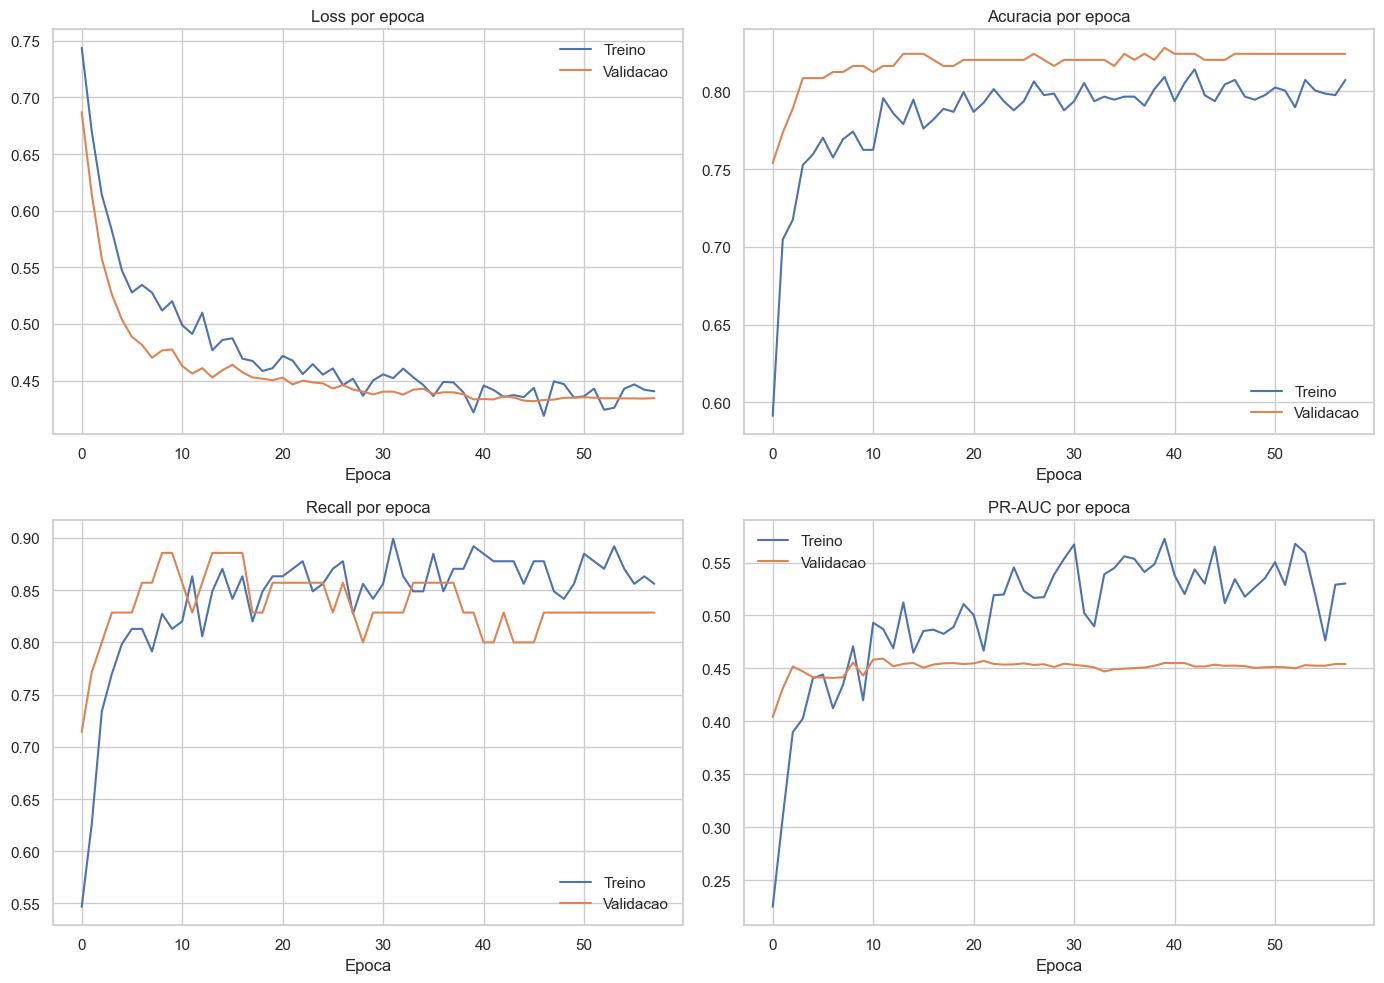

Total de epocas executadas: 58
Melhor val_loss observada: 0.4317


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(best_history.history["loss"], label="Treino")
axes[0, 0].plot(best_history.history["val_loss"], label="Validacao")
axes[0, 0].set_title("Loss por epoca")
axes[0, 0].set_xlabel("Epoca")
axes[0, 0].legend()

axes[0, 1].plot(best_history.history["accuracy"], label="Treino")
axes[0, 1].plot(best_history.history["val_accuracy"], label="Validacao")
axes[0, 1].set_title("Acuracia por epoca")
axes[0, 1].set_xlabel("Epoca")
axes[0, 1].legend()

axes[1, 0].plot(best_history.history["recall"], label="Treino")
axes[1, 0].plot(best_history.history["val_recall"], label="Validacao")
axes[1, 0].set_title("Recall por epoca")
axes[1, 0].set_xlabel("Epoca")
axes[1, 0].legend()

axes[1, 1].plot(best_history.history["pr_auc"], label="Treino")
axes[1, 1].plot(best_history.history["val_pr_auc"], label="Validacao")
axes[1, 1].set_title("PR-AUC por epoca")
axes[1, 1].set_xlabel("Epoca")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Total de epocas executadas: {len(best_history.history['loss'])}")
print(f"Melhor val_loss observada: {min(best_history.history['val_loss']):.4f}")


> **O que esta celula faz**  
> Gera os graficos finais de avaliacao: matriz de confusao, curva ROC, curva Precision-Recall e comparacao de `F1-score` entre os modelos. Esse conjunto resume o desempenho final e facilita a interpretacao dos resultados.


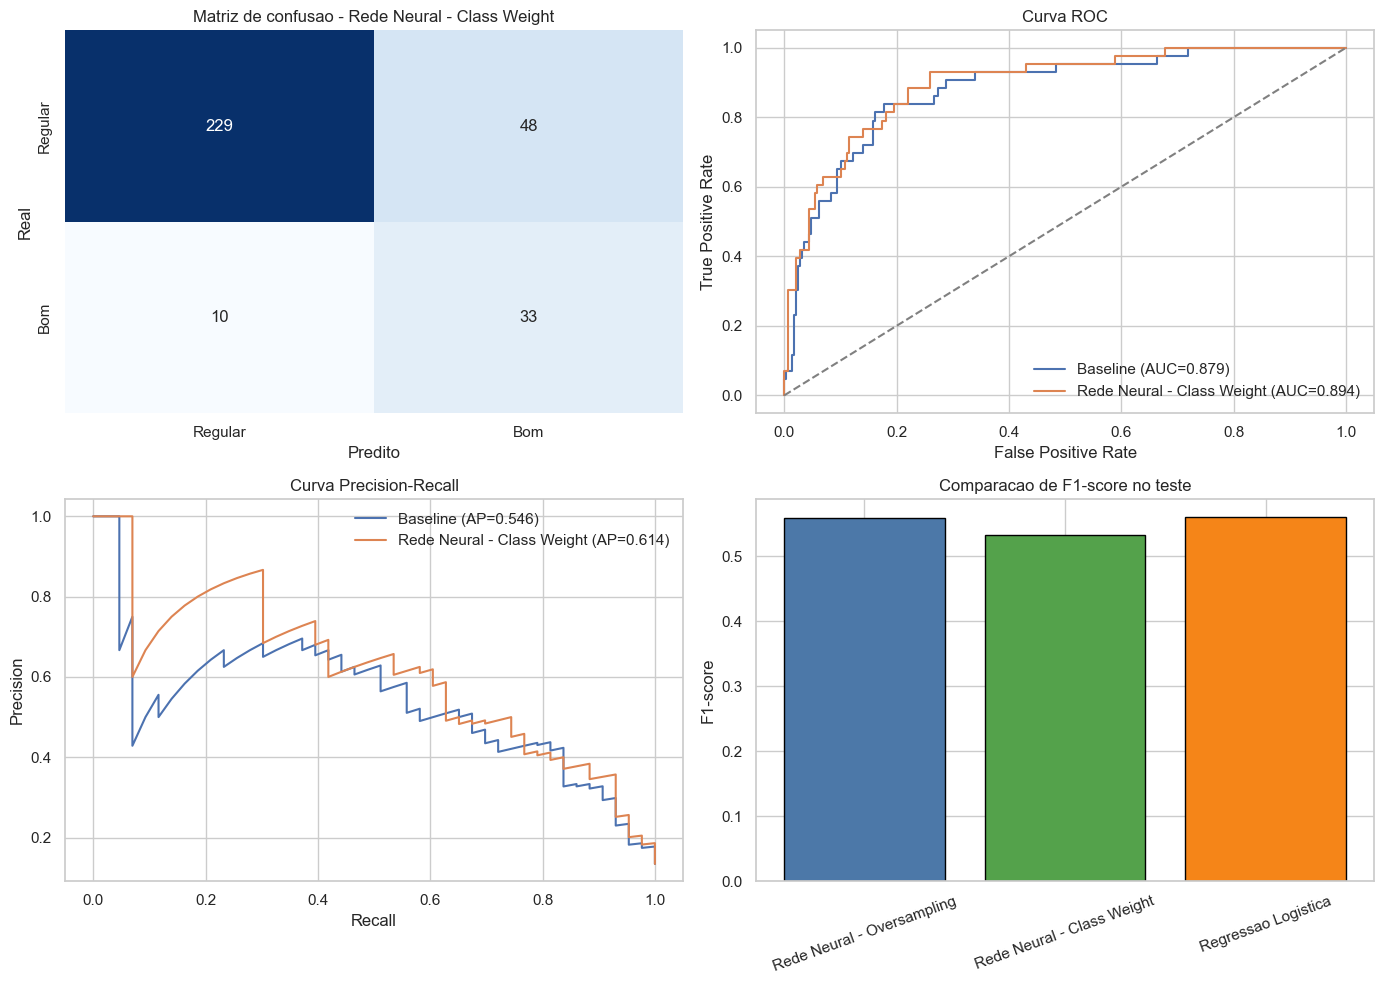

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cm_best = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 0])
axes[0, 0].set_title(f"Matriz de confusao - {best_model_name}")
axes[0, 0].set_xlabel("Predito")
axes[0, 0].set_ylabel("Real")
axes[0, 0].set_xticklabels(["Regular", "Bom"])
axes[0, 0].set_yticklabels(["Regular", "Bom"])

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_best, tpr_best, _ = roc_curve(y_test, best_scores)
axes[0, 1].plot(fpr_lr, tpr_lr, label=f"Baseline (AUC={metrics_lr['roc_auc']:.3f})")
axes[0, 1].plot(fpr_best, tpr_best, label=f"{best_model_name} (AUC={roc_auc_score(y_test, best_scores):.3f})")
axes[0, 1].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 1].set_title("Curva ROC")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend()

prec_lr_curve, rec_lr_curve, _ = precision_recall_curve(y_test, y_score_lr)
prec_best_curve, rec_best_curve, _ = precision_recall_curve(y_test, best_scores)
axes[1, 0].plot(rec_lr_curve, prec_lr_curve, label=f"Baseline (AP={metrics_lr['pr_auc']:.3f})")
axes[1, 0].plot(rec_best_curve, prec_best_curve, label=f"{best_model_name} (AP={average_precision_score(y_test, best_scores):.3f})")
axes[1, 0].set_title("Curva Precision-Recall")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()

axes[1, 1].bar(
    results_df["modelo"],
    results_df["f1"],
    color=["#4C78A8", "#54A24B", "#F58518"],
    edgecolor="black",
)
axes[1, 1].set_title("Comparacao de F1-score no teste")
axes[1, 1].set_ylabel("F1-score")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 8. Analise critica

As respostas abaixo devem ser ajustadas com os numeros obtidos ao executar o notebook no seu ambiente, mas a linha de raciocinio ja fica pronta para o relatorio.


**Q1. A rede neural superou o baseline de regressao logistica?**  
Compare principalmente `F1`, `ROC-AUC` e `PR-AUC`. Mesmo quando a rede neural vence, a diferenca pode ser pequena porque este dataset e relativamente pequeno (1599 amostras) e possui apenas 11 atributos numericos. Em problemas assim, um modelo linear bem regularizado costuma capturar grande parte do sinal. A rede neural tende a ajudar quando existem interacoes nao lineares entre atributos, mas o ganho pode ser limitado pelo tamanho do conjunto e pelo desbalanceamento.

**Q2. Trade-off entre precision e recall para a classe "bom".**  
Maior **precision** significa que, entre os vinhos classificados como bons, poucos serao falsos positivos. Isso e importante em um cenario de exportacao ou venda premium, em que rotular um vinho comum como excelente gera custo financeiro e reputacional. Maior **recall** significa encontrar a maior parte dos vinhos realmente bons, mesmo aceitando mais falsos positivos. Isso e mais util em um processo de triagem interna, em que vale a pena revisar manualmente os candidatos aprovados pelo modelo.

**Q3. Por que duas ou tres camadas menores podem funcionar melhor do que uma unica camada muito larga?**  
Embora o Teorema da Aproximacao Universal mostre que uma unica camada oculta suficientemente grande pode aproximar funcoes complexas, isso nao significa que ela seja a melhor opcao pratica. Redes mais profundas com menos neuronios por camada costumam reaproveitar representacoes intermediarias, aprender hierarquias mais eficientes, usar menos parametros e generalizar melhor. Uma camada unica muito larga aumenta custo computacional, risco de overfitting e dificuldade de otimizacao.

**Q4. Que validacoes adicionais seriam necessarias antes do uso em producao?**  
Antes de implantar o modelo em uma cooperativa, seria importante validar robustez em lotes novos, monitorar drift na distribuicao quimica ao longo do tempo e verificar estabilidade por safra, produtor e laboratorio. Tambem seria necessario testar calibracao das probabilidades, definir custos para falsos positivos e falsos negativos, estabelecer revisao humana para casos de baixa confianca e documentar a responsabilidade pelas decisoes tomadas a partir do modelo.
